# Survival Analysis: Time to Defibrillation vs. Patient Outcomes (Unbinned Logistic Regression)

This notebook analyzes the Out-of-Hospital Cardiac Arrest (OHCA) dataset to quantify how delay to first defibrillation affects patient outcomes.

Specifically, it uses **unbinned patient-level data** (one row per patient), computes **Time to First Defibrillation** from dispatch-call and first-shock timestamps, and fits two **logistic regression models** (`statsmodels.Logit`) over a constrained 0–20 minute window:

- **Predictor (X):** Time to First Defibrillation (minutes)
- **Outcome 1 (y):** Survival Status (1 = Survived, 0 = Dead)
- **Outcome 2 (y):** CPC Status (1 = Good CPC 1–2, 0 = Poor CPC 3–5)

Key outputs include:

- Logistic regression coefficient estimates, p-values, and model summaries
- **Odds Ratio** interpretation for each 1-minute delay (Survival and CPC)
- Fitted probability curves for Survival and CPC across 0–20 minutes
- A combined visualization comparing both modeled outcome curves

This provides a standard epidemiological estimate of the time–outcome relationship without time binning or exponential curve fitting.

# Need to install decryption Libraries

In [ ]:
%pip install msoffcrypto-tool openpyxl

# Install libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import msoffcrypto
import io
import openpyxl
import statsmodels.api as sm
from scipy.optimize import curve_fit
import seaborn as sns

from pathlib import Path

# Get the password from env

In [2]:
password = os.getenv("PAROS_PASSWORD")

if not password:
    print("ERROR: Password not found in the env")
else:
    print("SUCCESS: Password found in the env")

SUCCESS: Password found in the env


# Setting up file paths

In [3]:
CURRENT_DIRECTORY = Path(os.getcwd())
BASE_DATASET_PATH = CURRENT_DIRECTORY.parents[0] / "datasets"
ENCRYPTED_FILE_PATH = BASE_DATASET_PATH / "DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx"

display(ENCRYPTED_FILE_PATH)


PosixPath('/Users/axlee/Desktop/Singhealth/AED-OHCA/datasets/DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx')

# Decrypting the file

In [4]:
decrypted_workbook = io.BytesIO()
print(f"Attempting to decrypt: {ENCRYPTED_FILE_PATH.name}...")

try:
    with open(ENCRYPTED_FILE_PATH, 'rb') as file:
        office_file = msoffcrypto.OfficeFile(file)
        office_file.load_key(password=password)
        office_file.decrypt(decrypted_workbook)

    # Load the decrypted memory object directly into a Pandas DataFrame
    df = pd.read_excel(decrypted_workbook)
    print("✅ RAW PAROS dataset successfully decrypted and loaded!")
    
    # Show the first 3 rows to confirm
    # display(df.head(3))

except FileNotFoundError:
    print(f"❌ Error: Could not find the file at {ENCRYPTED_FILE_PATH}. Please check the path and filename.")
except openpyxl.utils.exceptions.InvalidFileException:
    print("❌ Error: Invalid password or unsupported Excel format.")
except Exception as e:
    print(f"❌ An error occurred: {e}")

Attempting to decrypt: DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx...


/opt/miniconda3/envs/geospatial_env/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


✅ RAW PAROS dataset successfully decrypted and loaded!


In [5]:
print(df.columns.tolist())


['Case #', 'Country', 'City', 'Site #', 'Patient brought in by', 'Date of Incident', 'Location of incident', 'Location Unknown', 'Location Type', 'Location Type Other', 'Age', 'Age Modifier', 'Gender', 'Race', 'Medical History - No', 'Medical History - Unknown', 'Medical History - Heart disease', 'Medical History - Diabetes', 'Medical History - Cancer', 'Medical History - Hypertension', 'Medical History - Renal Disease', 'Medical History - Respiratory Disease', 'Medical History - Hyperlipidemia', 'Medical History - Stroke', 'Medical History - HIV', 'Medical History - Other', 'Time call received at dispatch center', 'No First Responder dispatched', 'Time First Responder dispatched', 'Time Ambulance dispatched', 'Time First Responder arrived at scene', 'Time Ambulance arrived at scene', 'Time EMS arrived at patient side', 'Time Ambulance left scene', 'Time Ambulance arrived at ED', 'Estimated time of arrest', 'Estimated time of arrest unknown', 'Arrest witnessed by', 'Bystander CPR', 'DA

# Cleaning PAROS Dataset

In [16]:
# strip whitespace from all string cells first
df = df.apply(lambda col: col.map(lambda x: x.strip() if isinstance(x, str) else x))

missing_tokens = [
    "", " ", "  ", "N/A", "n/a", "NA", "na", "NULL", "null", "None", "none", "-"
]
df = df.replace(missing_tokens, np.nan)

missing_summary = (
    df.isna().mean()
      .mul(100)
      .sort_values(ascending=False)
      .rename("missing_pct")
      .to_frame()
)
display(missing_summary.head(30))
display(df.head(3))

,missing_pct
Lidocaine,99.996511
Bicarbonate,99.989534
Amiodarone,99.975580
Patient neurological status - Unknown,99.972091
EQ-5D Anxiety/Depression,99.958137
EQ-5D Pain/Discomfort,99.951160
Atropine,99.916274
EQ-5D Unknown,99.905808
Defibrillation performed by - Bystander - Family,99.902320
Dextrose,99.881388


,Case #,Country,City,Site #,Patient brought in by,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,...,EQ-5D Unknown,EQ-5D Mobility,EQ-5D Self-care,EQ-5D Usual activities,EQ-5D Pain/Discomfort,EQ-5D Anxiety/Depression,EQ-5D VAS,General Comments,Date Created,Date Last Saved
0,SGSIN0213,SG,SIN,2,EMS,2010-04-01,470146.0,NaN,Home Residence,HDB Level 7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2011-02-22
1,SGSIN0218,SG,SIN,2,EMS,2010-04-01,520926.0,NaN,Home Residence,HDB Level 2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2011-02-22
2,SGSIN6480,SG,SIN,6,EMS,2010-04-01,560565.0,NaN,Healthcare Facility,NKF Dialysis Centre,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2012-04-18


In [19]:
col = "Country"  # change this
display(df[col].values).unique()

array(['SG', 'SG', 'SG', ..., 'SG', 'SG', 'SG'],
      shape=(28665,), dtype=object)

AttributeError: 'NoneType' object has no attribute 'unique'

# Setting columns for feature engineering

In [7]:
# This will be used to calculate time to defib
call_time_col = 'Time call received at dispatch center'
shock_time_col = 'Time of first shock given'

# This will be used to calculate into a binary status of 0/1 survival
status_col = 'Patient status'

df_survival = df.copy()
# display(df_survival[[call_time_col, shock_time_col, status_col]].head())

# Calculating the time to defib

In [8]:
df_survival["Call_Time"] = pd.to_datetime(df_survival[call_time_col].astype(str),
                                          format = "mixed",
                                          errors='coerce')
df_survival['Shock_Time'] = pd.to_datetime(df_survival[shock_time_col].astype(str),
                                           format='mixed',
                                           errors='coerce')

# Calculate the difference in minutes
df_survival['Time_to_Defib'] = (df_survival['Shock_Time'] - df_survival['Call_Time']).dt.total_seconds() / 60

# Fix midnight crossover overlaps
df_survival.loc[df_survival['Time_to_Defib'] < 0, 'Time_to_Defib'] += 1440

# display(df_survival[['Call_Time', 'Shock_Time', 'Time_to_Defib']].head(10))

Time to defib will show 13.9 minutes (standard decimal format)

Example (Index 0):
-   54 seconds ÷ 60 seconds = 0.90 minutes.
-   13 minutes + 0.90 minutes = 13.90 minutes.

# Feature Engineering for Survival Status

- 0 = Dead
- 1 = Survived

In [9]:
df_survival['Survival_Status'] = df_survival[status_col].astype(str).str.contains('Discharged|Alive|Remains', 
                                                                                  case=False, 
                                                                                  na=False
).astype(int)
df_survival['Survival_Status'] = df_survival['Survival_Status'].astype(int)

# display(df_survival[['Time_to_Defib', 'Survival_Status']].head())

# Filter to a standard range (e.g., 0-20 minutes)
- This is to avoid extreme outliers skewing the fit

In [10]:
df_plot = df_survival[(df_survival['Time_to_Defib'] >= 0) & (df_survival['Time_to_Defib'] <= 20)].copy()


# Creating 1-minute bins and calculate empirical survival probability
- np.floor rounds times down to the nearest minute 
- 3.4 mins -> 3 mins

In [11]:
df_plot['Time_Bin'] = np.floor(df_plot['Time_to_Defib'])

# Calculate empirical survival probability for each time bin
binned_data = df_plot.groupby('Time_Bin').agg(
    Survival_Probability=('Survival_Status', 'mean'),
    Count=('Survival_Status', 'count')
).reset_index()

# Create standard exponential regresion function and fit the curve to the binned data
- Try to do initial parameter guessing

In [12]:
def exp_decay(x, a, b):
    return a * np.exp(-b * x)

x_data = binned_data['Time_Bin']
y_data = binned_data['Survival_Probability']

# Fit the exponential decay model to the data
try:
    popt, _ = curve_fit(exp_decay,
                        x_data,
                        y_data,
                        p0=[0.5, 0.1])
    a_fit, b_fit = popt
except Exception as e:
    print(f"Curve fitting failed: {e}")
    a_fit, b_fit = 0.5, 0.1 # Fallbacks if standard fitting fails

# Generate a continuous smooth line for the fitted curve
x_fit_line = np.linspace(0, 20, 200)
y_fit_line = exp_decay(x_fit_line, a_fit, b_fit)

# Checking for data homogenity

In [13]:
# 1. Convert 'Date of Incident' to a proper datetime format 
df_survival['Date of Incident'] = pd.to_datetime(df_survival['Date of Incident'],
                                                 errors='coerce')

# 2. Extract just the Year into a new column, drop completely missing years to keep chart clean
df_survival['Year'] = df_survival['Date of Incident'].dt.year
df_homogeneity = df_survival.dropna(subset=['Year']).copy()
df_homogeneity['Year'] = df_homogeneity['Year'].astype(int)

# 3. Ensure 'Bystander CPR' is binary (1 for Yes, 0 for No)
df_homogeneity['Bystander_CPR_Binary'] = df_homogeneity['Bystander CPR'].astype(str).str.contains('Yes',
                                                                                                  case=False,
                                                                                                  na=False).astype(int)

# 4. Group by Year
yearly_stats = df_homogeneity.groupby('Year').agg(
    Total_Cases=('Case #', 'count'),          # Counts the number of rows per year
    CPR_Rate=('Bystander_CPR_Binary', 'mean') # Calculates the % of cases with CPR
).reset_index()

# Convert CPR rate to a clean percentage
yearly_stats['CPR_Rate'] = yearly_stats['CPR_Rate'] * 100

# Plotting Dual-Axis Chart

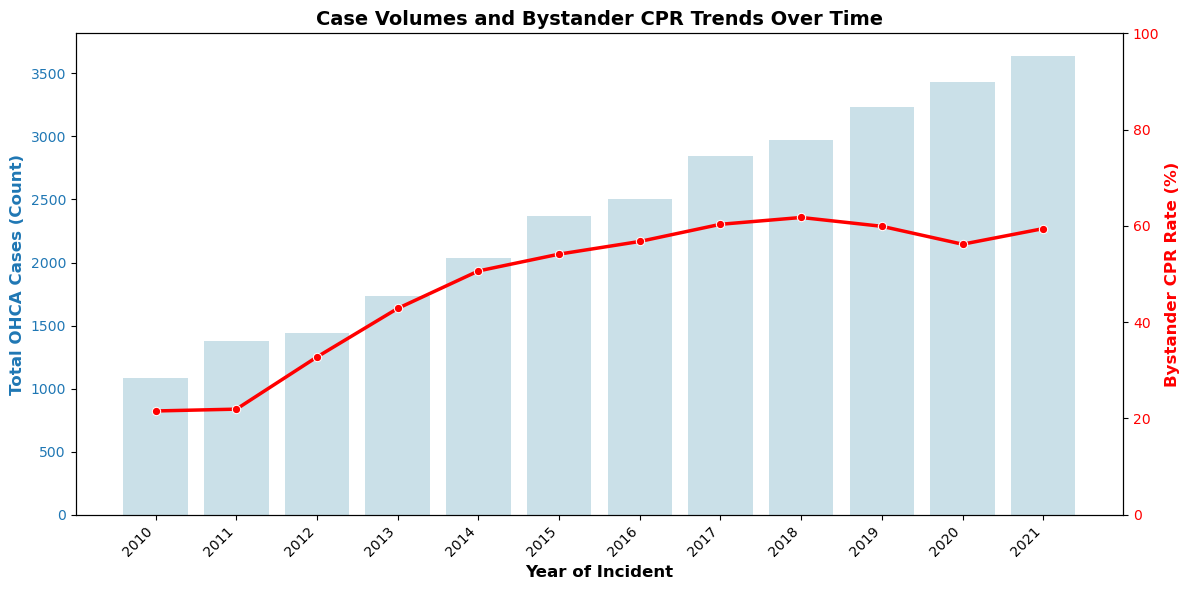

In [14]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Axis 1: Case Volumes (Bar Chart) ---
sns.barplot(data=yearly_stats,
            x='Year',
            y='Total_Cases',
            color='lightblue',
            ax=ax1,
            alpha=0.7)
ax1.set_ylabel('Total OHCA Cases (Count)',
               color='tab:blue',
               fontsize=12,
               fontweight='bold')
ax1.tick_params(axis='y',
                labelcolor='tab:blue')
ax1.set_xlabel('Year of Incident',
               fontsize=12,
               fontweight='bold')

# Rotate x-axis labels in case years get crowded
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# --- Axis 2: Bystander CPR Rate (Line Chart) ---
# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx() 
# Seaborn lineplot handles the secondary axis differently with categorical x-axis, 
# so we map to the index positions of the bars
sns.lineplot(x=range(len(yearly_stats)),
             y=yearly_stats['CPR_Rate'],
             color='red',
             marker='o',
             linewidth=2.5,
             ax=ax2)
ax2.set_ylabel('Bystander CPR Rate (%)',
               color='red',
               fontsize=12,
               fontweight='bold')
ax2.tick_params(axis='y',
                labelcolor='red')
ax2.set_ylim(0, 100) # Lock the percentage axis from 0 to 100

# Formatting
plt.title('Case Volumes and Bystander CPR Trends Over Time',
          fontsize=14,
          fontweight='bold')
ax1.grid(False)
ax2.grid(False) 
plt.tight_layout()

plt.show()

# Plot the 3-Way Baseline

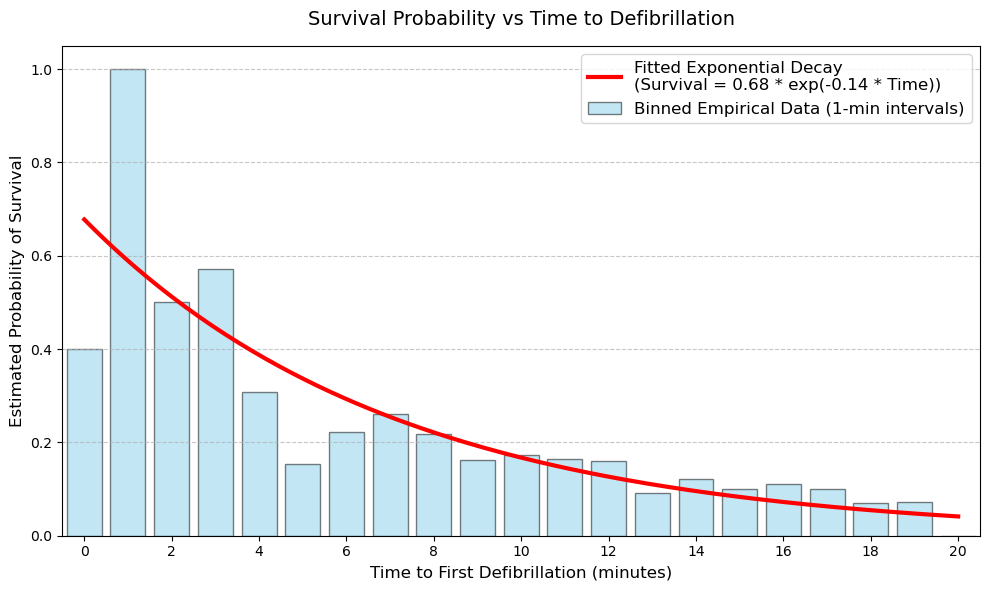

In [15]:
plt.figure(figsize=(10, 6))

# Histogram / Bar representation of the binned actual probabilities
plt.bar(x_data,
        y_data,
        width=0.8,
        alpha=0.5,
        color='skyblue',
        edgecolor='black', 
        label='Binned Empirical Data (1-min intervals)')

# Plot the exact scatter dots as well
# plt.scatter(x_data, y_data, color='blue', zorder=3)

# The smooth exponential curve
plt.plot(x_fit_line,
         y_fit_line,
         color='red',
         linewidth=3,
         label=f'Fitted Exponential Decay\n(Survival = {a_fit:.2f} * exp(-{b_fit:.2f} * Time))')

# Aesthetics
plt.title('Survival Probability vs Time to Defibrillation',
          fontsize=14,
          pad=15)
plt.xlabel('Time to First Defibrillation (minutes)',
           fontsize=12)
plt.ylabel('Estimated Probability of Survival',
           fontsize=12)
plt.xticks(np.arange(0, 21, 2))
plt.xlim(-0.5, 20.5)
plt.grid(axis='y',
         linestyle='--',
         alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()